In [6]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [7]:
df=pd.read_csv("homeprices.csv")
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


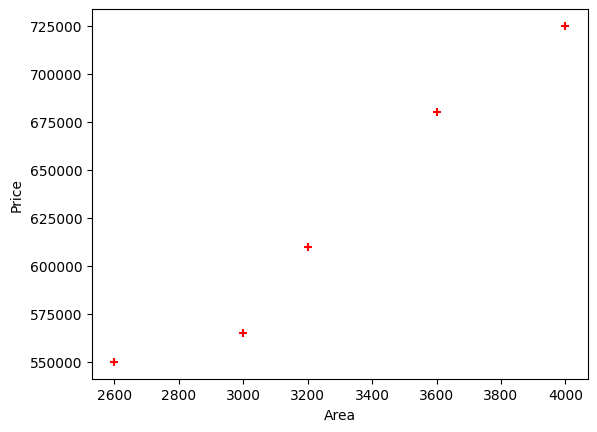

In [8]:
plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(df.area,df.price,color="red",marker="+")

In [9]:
area=df.drop("price",axis="columns")
area

,area
0,2600
1,3000
2,3200
3,3600
4,4000


In [10]:
price=df.price
price

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64

In [11]:
#Equation for linaer reg, y = mx+ c

reg=linear_model.LinearRegression()
reg.fit(area,price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
reg.coef_

array([135.78767123])

In [13]:
reg.intercept_

np.float64(180616.43835616432)

In [14]:
# To predict the new area 3500

new_data=pd.DataFrame([[3500]],columns=['area'])
prediction=reg.predict(new_data)
prediction=np.round(prediction,2)
prediction

array([655873.29])

In [15]:
135.78767123*3500+180616.43835616432

655873.2876611643

In [16]:
p=reg.predict(df[['area']])
p=np.round(p,2)
p

array([533664.38, 587979.45, 615136.99, 669452.05, 723767.12])

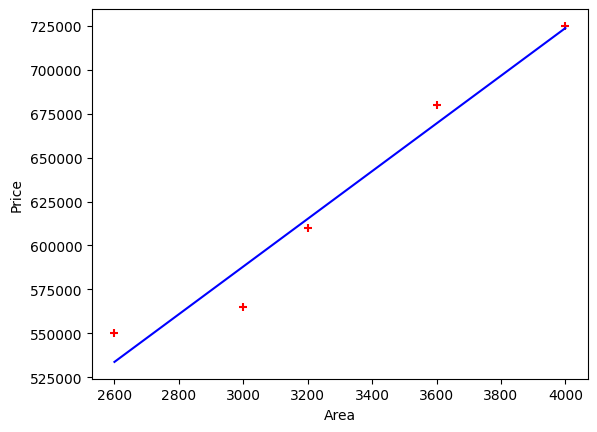

In [17]:
plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(df.area,df.price,color="red",marker="+")
plt.plot(df.area,reg.predict(df[['area']]),color='blue')

In [18]:
reg.score(df[['area']],df.price)

0.9584301138199486

In [19]:
# To predict the new area 6500 and 10000
new_data1=pd.DataFrame([[6500]],columns=['area'])
prediction1=reg.predict(new_data1)
prediction1=np.round(prediction1,2)
prediction1

array([1063236.3])

In [20]:
new_data2=pd.DataFrame([[10000]],columns=['area'])
prediction2=reg.predict(new_data2)
prediction2=np.round(prediction2,2)
prediction2

array([1538493.15])

In [21]:
d= pd.read_csv("areas.csv")
d.head()

FileNotFoundError: [Errno 2] No such file or directory: 'areas.csv'

In [ ]:
pred=reg.predict(d)
pred=np.round(pred,2)
pred

In [ ]:
d['predicted_price']=pred
d

In [ ]:
d.to_csv("predicted_areas.csv",index=False)

In [ ]:
reg.score(d[['area']],d.predicted_price)